# 04A - Pass/Fail Risk Model Hyperparameter Tuning

This notebook performs dedicated hyperparameter tuning for the **Pass/Fail Risk Model** in the Smart Learning System.

This is a core project model because it supports:

- Parent risk notifications
- Teacher weak-student detection
- Early pass/fail intervention decisions

## 1. Notebook Objectives

This notebook will:

- Load the processed Pass/Fail dataset from `02_Data_Preprocessing.ipynb`.
- Use the same feature and target definitions from `03A_Pass_Fail_Model.ipynb`.
- Compare baseline Logistic Regression, Decision Tree and Random Forest models.
- Tune the same candidate models using `GridSearchCV`.
- Evaluate tuned models using accuracy, balanced accuracy, precision, recall, F1-score and cross-validation results.
- Select the best tuned Pass/Fail model.
- Export tuning reports, best parameters, classification report and confusion matrix.

In [1]:
from pathlib import Path
import json
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display as display_image

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

## 2. Resolve Project Paths

In [2]:
def find_ml_root(start_path=Path.cwd()):
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        if candidate.name == "ml-model" and (candidate / "datasets").exists():
            return candidate
        nested = candidate / "ml-model"
        if nested.exists() and (nested / "datasets").exists():
            return nested
    raise FileNotFoundError("Could not locate ml-model directory. Run this notebook inside the project repository.")

ML_ROOT = find_ml_root()
PROCESSED_DIR = ML_ROOT / "datasets" / "processed"
REPORTS_DIR = ML_ROOT / "outputs" / "reports"
FIGURES_DIR = ML_ROOT / "outputs" / "figures"
TUNING_DIR = ML_ROOT / "outputs" / "tuning"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TUNING_DIR.mkdir(parents=True, exist_ok=True)

PASS_FAIL_DATASET = PROCESSED_DIR / "pass_fail_processed.csv"
METADATA_PATH = PROCESSED_DIR / "preprocessing_metadata.json"

print("ML root:", ML_ROOT)
print("Pass/Fail dataset:", PASS_FAIL_DATASET)
print("Tuning directory:", TUNING_DIR)
print("Figures directory:", FIGURES_DIR)

ML root: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model
Pass/Fail dataset: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed/pass_fail_processed.csv
Tuning directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning
Figures directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures


## 3. Load Preprocessing Metadata

The preprocessing metadata stores the approved feature list, target column and leakage-prevention statement.

In [3]:
if METADATA_PATH.exists():
    metadata = json.loads(METADATA_PATH.read_text())
else:
    metadata = {}

pass_fail_features = metadata.get("pass_fail_features", [
    "attendance_pct",
    "homework_pct",
    "midterm_score",
    "study_hours_per_week",
])
pass_fail_target = metadata.get("pass_fail_target", "pass")
pass_fail_meaning = metadata.get("pass_fail_target_meaning", {"0": "Fail", "1": "Pass"})

print("Features:", pass_fail_features)
print("Target:", pass_fail_target)
print("Target meaning:", pass_fail_meaning)
print("Data leakage note:", metadata.get("data_leakage_prevention", "Pipeline transformations are fitted on training data only."))

Features: ['attendance_pct', 'homework_pct', 'midterm_score', 'study_hours_per_week']
Target: pass
Target meaning: {'0': 'Fail', '1': 'Pass'}
Data leakage note: Scaling, fitted imputation, encoding objects and resampling are fitted only on the training split during model training.


## 4. Data Leakage Prevention

This notebook does not fit preprocessing transformations on the full dataset.

- Missing-value imputation is inside the pipeline.
- Feature scaling is inside the pipeline.
- `GridSearchCV` tunes the full pipeline, so preprocessing is fitted only inside training folds.
- The target column `pass` is never included in the feature matrix.

## 5. Load Pass/Fail Processed Dataset

In [4]:
if not PASS_FAIL_DATASET.exists():
    raise FileNotFoundError(f"Missing dataset: {PASS_FAIL_DATASET}. Run 02_Data_Preprocessing.ipynb first.")

pass_fail_df = pd.read_csv(PASS_FAIL_DATASET)
print("Dataset shape:", pass_fail_df.shape)
display(pass_fail_df.head())

Dataset shape: (100, 6)


,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0


## 6. Validate Columns and Data Types

In [5]:
required_columns = pass_fail_features + [pass_fail_target]
missing_columns = [column for column in required_columns if column not in pass_fail_df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are available.")
display(pd.DataFrame({"Data Type": pass_fail_df[required_columns].dtypes.astype(str)}))

All required columns are available.


,Data Type
attendance_pct,int64
homework_pct,int64
midterm_score,int64
study_hours_per_week,int64
pass,int64


## 7. Class Distribution

Target values:

- `0` = Fail
- `1` = Pass

In [6]:
target_counts = pass_fail_df[pass_fail_target].value_counts().sort_index()
target_percentages = pass_fail_df[pass_fail_target].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2),
})

display(class_summary)

class_summary_path = TUNING_DIR / "pass_fail_tuning_class_distribution.csv"
class_summary.to_csv(class_summary_path)
print("Saved:", class_summary_path)

,Count,Percentage
pass,,
0,40,40.0
1,60,60.0


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/pass_fail_tuning_class_distribution.csv


## 8. Feature and Target Separation

In [7]:
X = pass_fail_df[pass_fail_features].copy()
y = pass_fail_df[pass_fail_target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (100, 4)
y shape: (100,)


,attendance_pct,homework_pct,midterm_score,study_hours_per_week
0,95,92,88,12
1,88,85,79,10
2,60,55,58,4
3,72,70,65,6
4,40,45,50,3


## 9. Train/Test Split

A stratified split keeps Pass and Fail proportions similar in both sets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "Split": ["Training", "Testing"],
    "Rows": [len(y_train), len(y_test)],
    "Fail Count": [int((y_train == 0).sum()), int((y_test == 0).sum())],
    "Pass Count": [int((y_train == 1).sum()), int((y_test == 1).sum())],
})

display(split_summary)

,Split,Rows,Fail Count,Pass Count
0,Training,80,32,48
1,Testing,20,8,12


## 10. Helper Functions

In [9]:
def calculate_binary_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "Macro F1 Score": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1 Score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def make_baseline_models():
    return {
        "Logistic Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")),
        ]),
        "Decision Tree": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced", max_depth=5)),
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced")),
        ]),
    }


def make_tuning_grids():
    return {
        "Logistic Regression": (
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=1500, random_state=RANDOM_STATE, class_weight="balanced")),
            ]),
            {
                "model__C": [0.01, 0.1, 1.0, 10.0],
                "model__solver": ["lbfgs", "liblinear"],
            },
        ),
        "Decision Tree": (
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
            ]),
            {
                "model__criterion": ["gini", "entropy"],
                "model__max_depth": [2, 3, 5, 8, None],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 4],
            },
        ),
        "Random Forest": (
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
            ]),
            {
                "model__n_estimators": [100, 200, 300],
                "model__max_depth": [None, 4, 8],
                "model__min_samples_split": [2, 5],
                "model__min_samples_leaf": [1, 2],
                "model__max_features": ["sqrt", "log2"],
            },
        ),
    }


def save_confusion_matrix(y_true, y_pred, title, output_path):
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
    display_obj = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Fail", "Pass"],
    )
    fig, ax = plt.subplots(figsize=(6, 5))
    display_obj.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", output_path)
    display_image(Image(filename=str(output_path)))

## 11. Baseline Model Evaluation

In [10]:
baseline_rows = []
baseline_models = make_baseline_models()
baseline_predictions = {}

for model_name, model in baseline_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    baseline_predictions[model_name] = y_pred
    baseline_rows.append({
        "Model": model_name,
        "Version": "Baseline",
        **calculate_binary_metrics(y_test, y_pred),
    })

baseline_df = pd.DataFrame(baseline_rows).round(4)
display(baseline_df)

baseline_path = TUNING_DIR / "pass_fail_baseline_scores.csv"
baseline_df.to_csv(baseline_path, index=False)
print("Saved:", baseline_path)

,Model,Version,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Macro F1 Score,Weighted F1 Score
0,Logistic Regression,Baseline,1.00,1.0000,1.0,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,Baseline,0.95,0.9583,1.0,0.9167,0.9565,0.9488,0.9504
2,Random Forest,Baseline,1.00,1.0000,1.0,1.0000,1.0000,1.0000,1.0000


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/pass_fail_baseline_scores.csv


## 12. Hyperparameter Search Space

In [11]:
tuning_grids = make_tuning_grids()

for model_name, (_, param_grid) in tuning_grids.items():
    combinations = 1
    for values in param_grid.values():
        combinations *= len(values)
    print(f"{model_name}: {combinations} parameter combinations")

Logistic Regression: 8 parameter combinations
Decision Tree: 90 parameter combinations
Random Forest: 72 parameter combinations


## 13. Run GridSearchCV Tuning

The scoring metric is `balanced_accuracy`, because this Pass/Fail problem should treat Fail and Pass classes fairly.

In [12]:
minimum_class_count = int(y_train.value_counts().min())
n_splits = min(5, minimum_class_count)
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

tuning_rows = []
tuned_models = {}
tuned_predictions = {}
all_cv_results = []

for model_name, (pipeline, param_grid) in tuning_grids.items():
    print("Running GridSearchCV:", model_name)
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=None,
        refit=True,
        return_train_score=True,
    )
    search.fit(X_train, y_train)

    tuned_model = search.best_estimator_
    y_pred = tuned_model.predict(X_test)

    tuned_models[model_name] = tuned_model
    tuned_predictions[model_name] = y_pred

    tuning_rows.append({
        "Model": model_name,
        "Version": "Tuned",
        "Best CV Balanced Accuracy": search.best_score_,
        "Best Parameters": json.dumps(search.best_params_),
        "CV Folds": n_splits,
        **calculate_binary_metrics(y_test, y_pred),
    })

    cv_results_df = pd.DataFrame(search.cv_results_)
    cv_results_df["Model"] = model_name
    all_cv_results.append(cv_results_df)

tuning_df = pd.DataFrame(tuning_rows).round(4)
display(tuning_df)

tuning_results_path = TUNING_DIR / "pass_fail_tuning_results.csv"
tuning_df.to_csv(tuning_results_path, index=False)
print("Saved:", tuning_results_path)

cv_results_path = TUNING_DIR / "pass_fail_tuning_cv_results.csv"
pd.concat(all_cv_results, ignore_index=True).to_csv(cv_results_path, index=False)
print("Saved:", cv_results_path)

Running GridSearchCV: Logistic Regression
Running GridSearchCV: Decision Tree
Running GridSearchCV: Random Forest


,Model,Version,Best CV Balanced Accuracy,Best Parameters,CV Folds,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Macro F1 Score,Weighted F1 Score
0,Logistic Regression,Tuned,0.9900,"{""model__C"": 1.0, ""model__solver"": ""lbfgs""}",5,1.00,1.0000,1.0,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,Tuned,0.9857,"{""model__criterion"": ""gini"", ""model__max_depth...",5,0.95,0.9583,1.0,0.9167,0.9565,0.9488,0.9504
2,Random Forest,Tuned,1.0000,"{""model__max_depth"": null, ""model__max_feature...",5,1.00,1.0000,1.0,1.0000,1.0000,1.0000,1.0000


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/pass_fail_tuning_results.csv
Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/pass_fail_tuning_cv_results.csv


## 14. Baseline vs Tuned Comparison

In [13]:
comparison_df = pd.concat([baseline_df, tuning_df], ignore_index=True, sort=False)
comparison_df = comparison_df.sort_values(
    by=["Balanced Accuracy", "F1 Score", "Accuracy", "Macro F1 Score"],
    ascending=False,
).reset_index(drop=True)

display(comparison_df)

comparison_path = TUNING_DIR / "pass_fail_baseline_vs_tuned_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

,Model,Version,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Macro F1 Score,Weighted F1 Score,Best CV Balanced Accuracy,Best Parameters,CV Folds
0,Logistic Regression,Baseline,1.00,1.0000,1.0,1.0000,1.0000,1.0000,1.0000,NaN,NaN,NaN
1,Random Forest,Baseline,1.00,1.0000,1.0,1.0000,1.0000,1.0000,1.0000,NaN,NaN,NaN
2,Logistic Regression,Tuned,1.00,1.0000,1.0,1.0000,1.0000,1.0000,1.0000,0.9900,"{""model__C"": 1.0, ""model__solver"": ""lbfgs""}",5.0
3,Random Forest,Tuned,1.00,1.0000,1.0,1.0000,1.0000,1.0000,1.0000,1.0000,"{""model__max_depth"": null, ""model__max_feature...",5.0
4,Decision Tree,Baseline,0.95,0.9583,1.0,0.9167,0.9565,0.9488,0.9504,NaN,NaN,NaN
5,Decision Tree,Tuned,0.95,0.9583,1.0,0.9167,0.9565,0.9488,0.9504,0.9857,"{""model__criterion"": ""gini"", ""model__max_depth...",5.0


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/pass_fail_baseline_vs_tuned_comparison.csv


## 15. Select Best Tuned Model

The best tuned model is selected using:

1. Balanced Accuracy
2. F1 Score
3. Accuracy
4. Simplicity, if performance is tied

In [14]:
tuned_only = tuning_df.sort_values(
    by=["Balanced Accuracy", "F1 Score", "Accuracy", "Best CV Balanced Accuracy"],
    ascending=False,
).reset_index(drop=True)

best_model_name = tuned_only.iloc[0]["Model"]
best_model = tuned_models[best_model_name]
best_predictions = tuned_predictions[best_model_name]
best_params = json.loads(tuned_only.iloc[0]["Best Parameters"])

print("Best tuned Pass/Fail model:", best_model_name)
print("Best parameters:", best_params)
display(tuned_only.head(1))

Best tuned Pass/Fail model: Random Forest
Best parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}


,Model,Version,Best CV Balanced Accuracy,Best Parameters,CV Folds,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Macro F1 Score,Weighted F1 Score
0,Random Forest,Tuned,1.0,"{""model__max_depth"": null, ""model__max_feature...",5,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 16. Best Tuned Model Classification Report

In [15]:
report_text = classification_report(
    y_test,
    best_predictions,
    target_names=["Fail", "Pass"],
    zero_division=0,
)
print(report_text)

report_dict = classification_report(
    y_test,
    best_predictions,
    target_names=["Fail", "Pass"],
    output_dict=True,
    zero_division=0,
)

report_path = TUNING_DIR / "pass_fail_best_tuned_classification_report.json"
report_path.write_text(json.dumps(report_dict, indent=2))
print("Saved:", report_path)

              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         8
        Pass       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/pass_fail_best_tuned_classification_report.json


## 17. Best Tuned Model Confusion Matrix

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/pass_fail_best_tuned_confusion_matrix.png


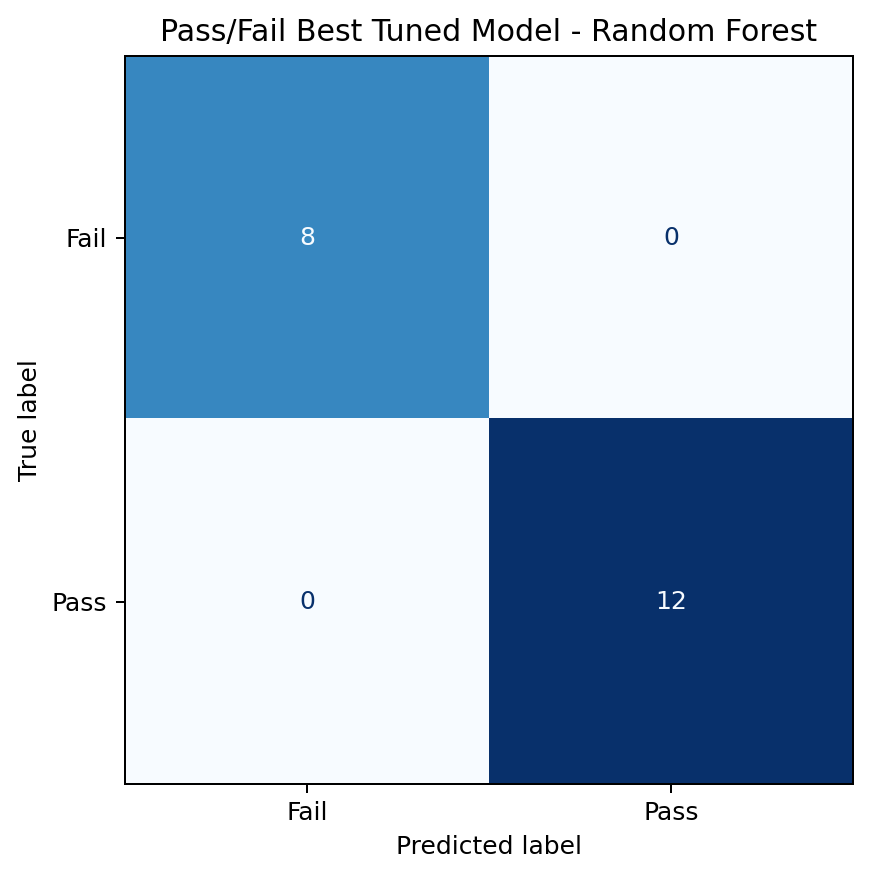

In [16]:
best_cm_path = FIGURES_DIR / "pass_fail_best_tuned_confusion_matrix.png"
save_confusion_matrix(
    y_test,
    best_predictions,
    f"Pass/Fail Best Tuned Model - {best_model_name}",
    best_cm_path,
)

## 18. Confusion Matrices for All Tuned Models

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/pass_fail_tuned_logistic_regression_confusion_matrix.png


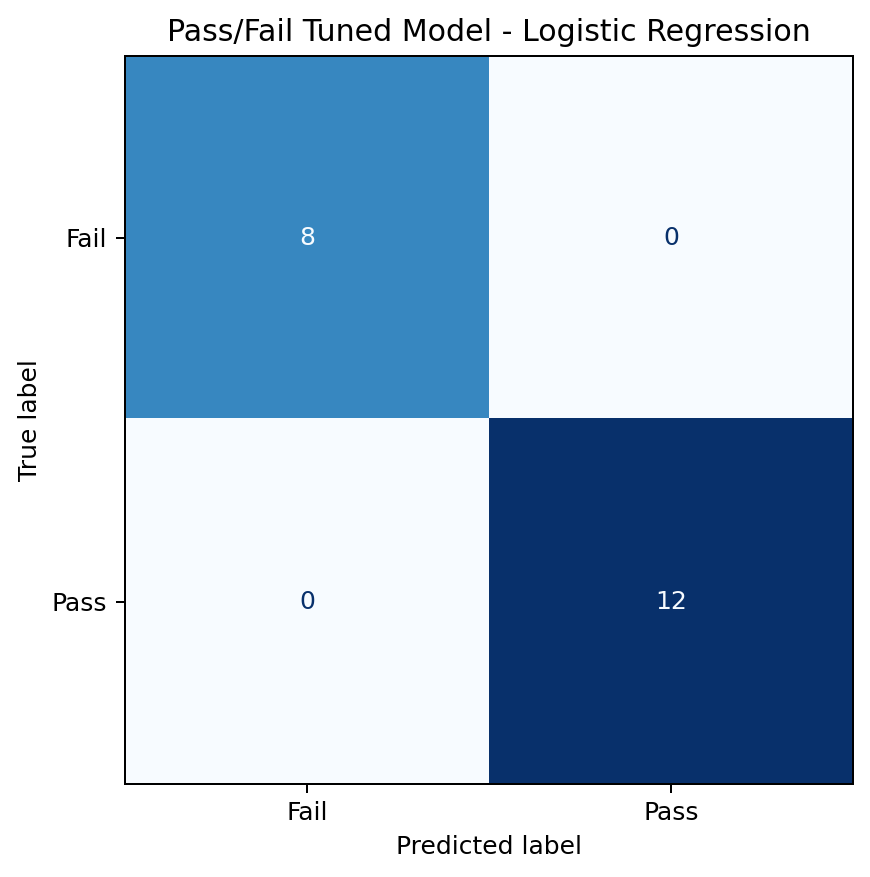

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/pass_fail_tuned_decision_tree_confusion_matrix.png


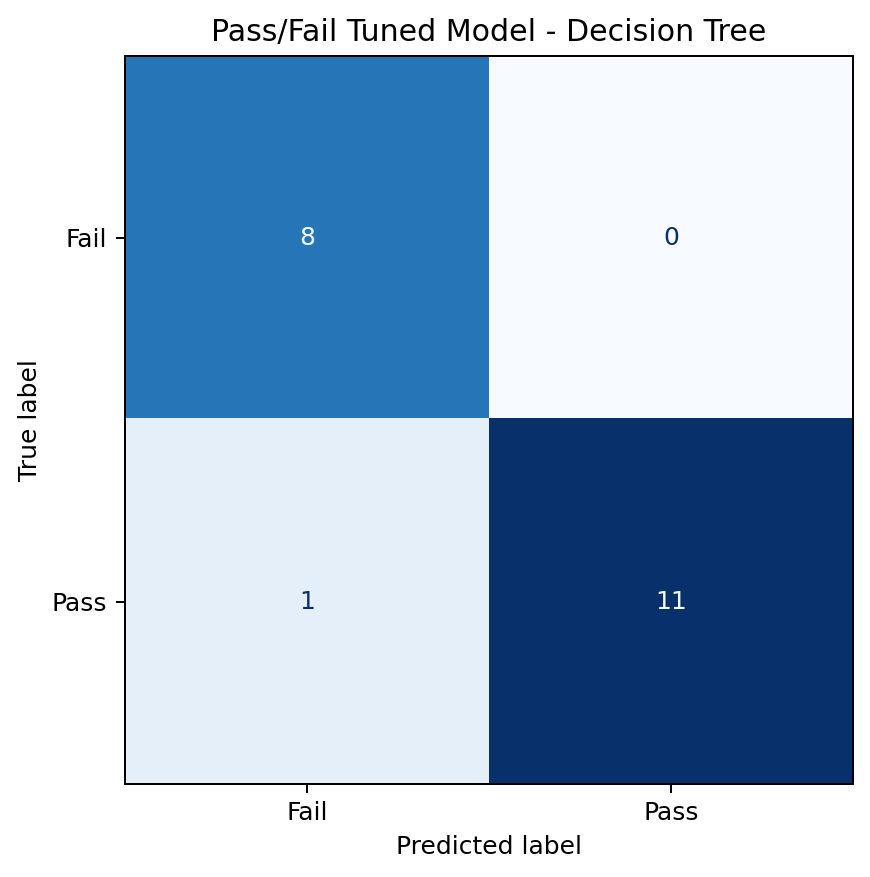

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/pass_fail_tuned_random_forest_confusion_matrix.png


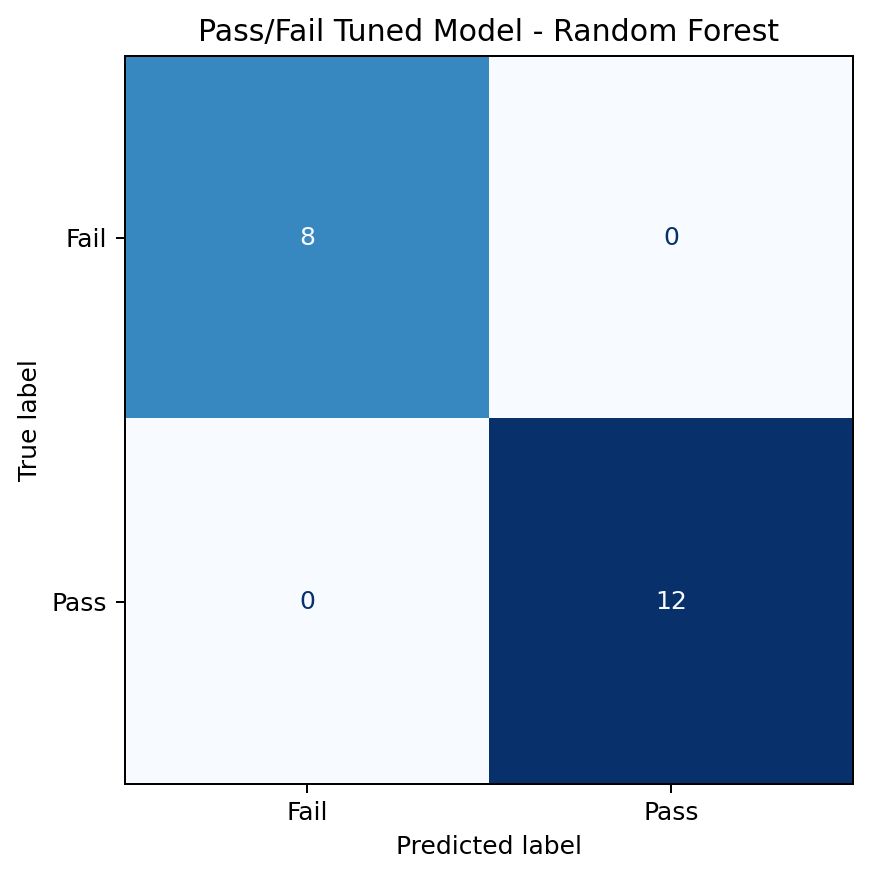

In [17]:
for model_name, y_pred in tuned_predictions.items():
    safe_name = model_name.lower().replace(" ", "_")
    output_path = FIGURES_DIR / f"pass_fail_tuned_{safe_name}_confusion_matrix.png"
    save_confusion_matrix(
        y_test,
        y_pred,
        f"Pass/Fail Tuned Model - {model_name}",
        output_path,
    )

## 19. Feature Importance / Coefficient Analysis

In [18]:
importance_rows = []

for model_name, pipeline in tuned_models.items():
    model_step = pipeline.named_steps["model"]
    if hasattr(model_step, "feature_importances_"):
        values = model_step.feature_importances_
        importance_type = "feature_importance"
    elif hasattr(model_step, "coef_"):
        values = np.abs(model_step.coef_[0])
        importance_type = "absolute_coefficient"
    else:
        continue

    for feature, value in zip(pass_fail_features, values):
        importance_rows.append({
            "Model": model_name,
            "Importance Type": importance_type,
            "Feature": feature,
            "Value": float(value),
        })

importance_df = pd.DataFrame(importance_rows).sort_values(["Model", "Value"], ascending=[True, False])
display(importance_df.round(4))

importance_path = TUNING_DIR / "pass_fail_tuned_feature_importance.csv"
importance_df.to_csv(importance_path, index=False)
print("Saved:", importance_path)

,Model,Importance Type,Feature,Value
4,Decision Tree,feature_importance,attendance_pct,1.0000
5,Decision Tree,feature_importance,homework_pct,0.0000
6,Decision Tree,feature_importance,midterm_score,0.0000
7,Decision Tree,feature_importance,study_hours_per_week,0.0000
0,Logistic Regression,absolute_coefficient,attendance_pct,1.4637
1,Logistic Regression,absolute_coefficient,homework_pct,1.4250
3,Logistic Regression,absolute_coefficient,study_hours_per_week,1.3200
2,Logistic Regression,absolute_coefficient,midterm_score,1.2558
9,Random Forest,feature_importance,homework_pct,0.3400
8,Random Forest,feature_importance,attendance_pct,0.3100


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/pass_fail_tuned_feature_importance.csv


## 20. Best Parameter Table

In [19]:
best_parameter_rows = [
    {"Model": best_model_name, "Parameter": parameter, "Value": value}
    for parameter, value in best_params.items()
]

best_parameters_df = pd.DataFrame(best_parameter_rows)
display(best_parameters_df)

best_parameters_path = TUNING_DIR / "pass_fail_best_tuned_parameters.csv"
best_parameters_df.to_csv(best_parameters_path, index=False)
print("Saved:", best_parameters_path)

,Model,Parameter,Value
0,Random Forest,model__max_depth,None
1,Random Forest,model__max_features,sqrt
2,Random Forest,model__min_samples_leaf,1
3,Random Forest,model__min_samples_split,2
4,Random Forest,model__n_estimators,100


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/pass_fail_best_tuned_parameters.csv


## 21. Documentation Summary

In [20]:
summary = {
    "notebook": "04A_Pass_Fail_Tuning.ipynb",
    "model_purpose": "Pass/Fail risk prediction for weak-student detection and parent risk notification",
    "dataset": str(PASS_FAIL_DATASET),
    "rows": int(pass_fail_df.shape[0]),
    "features": pass_fail_features,
    "target": pass_fail_target,
    "target_meaning": pass_fail_meaning,
    "candidate_models": list(tuning_grids.keys()),
    "best_tuned_model": best_model_name,
    "best_parameters": best_params,
    "selection_metric": "Balanced Accuracy with F1 Score and Accuracy as supporting metrics",
    "random_state": RANDOM_STATE,
    "data_leakage_prevention": "Imputation and scaling are fitted inside the training pipeline and cross-validation folds only.",
    "tuning_results_file": str(tuning_results_path),
    "comparison_file": str(comparison_path),
    "classification_report_file": str(report_path),
    "confusion_matrix_file": str(best_cm_path),
}

summary_path = TUNING_DIR / "pass_fail_tuning_summary.json"
summary_path.write_text(json.dumps(summary, indent=2))
print("Saved:", summary_path)

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/pass_fail_tuning_summary.json


## 23. Final Conclusion

This notebook completed dedicated hyperparameter tuning for the Pass/Fail Risk Model. Logistic Regression, Decision Tree and Random Forest models were tuned using leakage-safe pipelines and stratified cross-validation.

The best tuned model was selected using balanced accuracy, F1-score and test-set performance. The generated reports, best parameters, classification report and confusion matrices are ready to be used in `05_Final_Evaluation_Export.ipynb` when exporting the final Pass/Fail model files.